In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Mall_Customers.csv')
print("Shape of dataset:", df.shape)
print("\nDataset Info:")
df.info()
print("\nFirst 10 rows:")
display(df.head(10))

rename_dict = {
    'Genre': 'Gender',
    'Annual Income (k$)': 'AnnualIncome',
    'Spending Score (1-100)': 'SpendingScore'
}
df.rename(columns=rename_dict, inplace=True)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nGender Count:")
print(df['Gender'].value_counts())

Shape of dataset: (200, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

First 10 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72



Missing Values:
CustomerID       0
Gender           0
Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64

Gender Count:
Gender
Female    112
Male       88
Name: count, dtype: int64


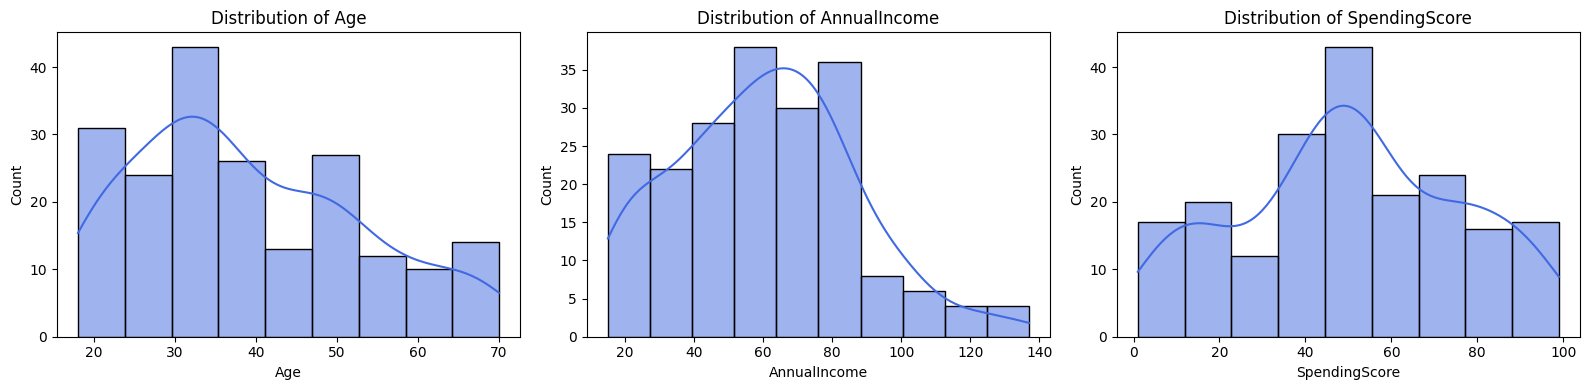

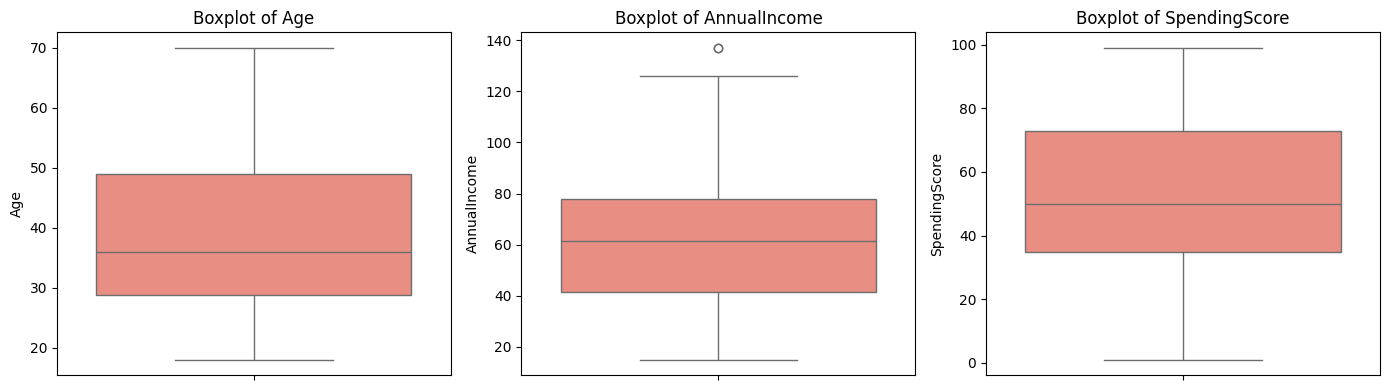

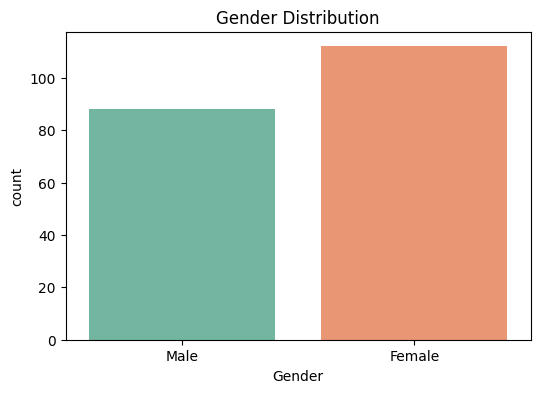

In [10]:
num_cols = ['Age', 'AnnualIncome', 'SpendingScore']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Gender Distribution')
plt.show()

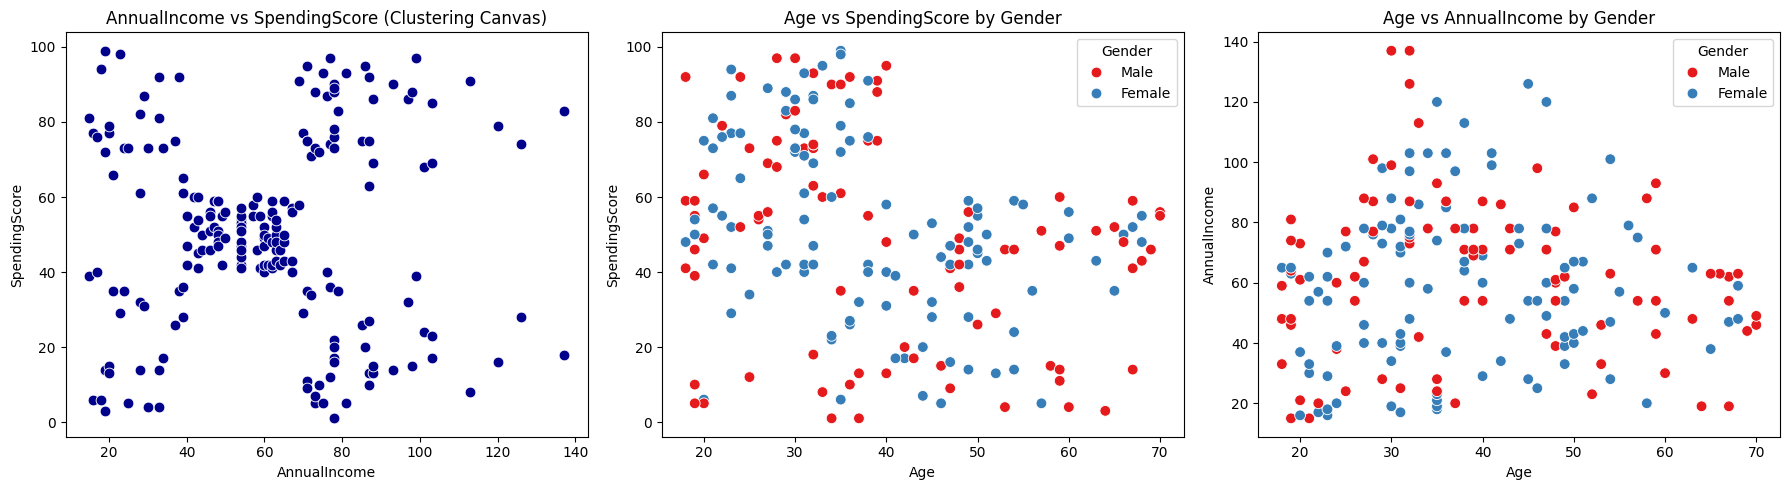

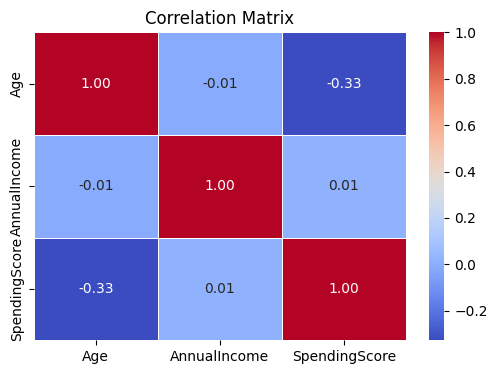

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='AnnualIncome', y='SpendingScore', ax=axes[0], s=60, color='darkblue')
axes[0].set_title('AnnualIncome vs SpendingScore (Clustering Canvas)')

sns.scatterplot(data=df, x='Age', y='SpendingScore', hue='Gender', ax=axes[1], s=60, palette='Set1')
axes[1].set_title('Age vs SpendingScore by Gender')

sns.scatterplot(data=df, x='Age', y='AnnualIncome', hue='Gender', ax=axes[2], s=60, palette='Set1')
axes[2].set_title('Age vs AnnualIncome by Gender')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Gender-wise Metric Means:


,Age,AnnualIncome,SpendingScore
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


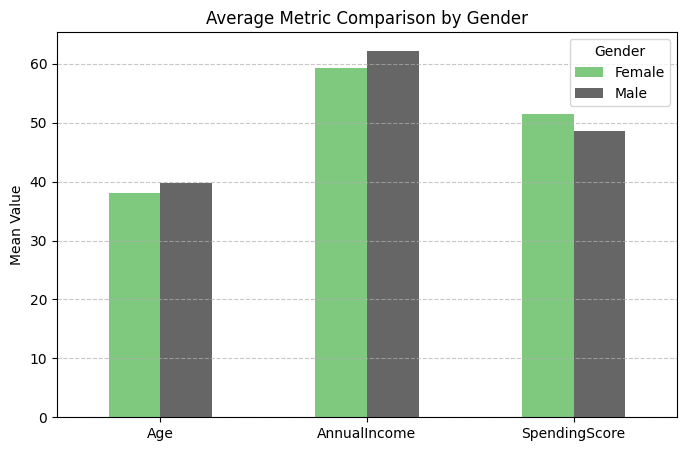

In [12]:
gender_summary = df.groupby('Gender')[num_cols].mean()
print("Gender-wise Metric Means:")
display(gender_summary)

gender_summary.T.plot(kind='bar', figsize=(8, 5), colormap='Accent')
plt.title('Average Metric Comparison by Gender')
plt.ylabel('Mean Value')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Initial Clustering Canvas Inspection
The scatter plot of **AnnualIncome vs SpendingScore** displays **5 distinct visual clusters**:
1. **Low Income, Low Spending** (Bottom-Left)
2. **Low Income, High Spending** (Top-Left)
3. **Medium Income, Medium Spending** (Dense Center Cluster)
4. **High Income, Low Spending** (Bottom-Right)
5. **High Income, High Spending** (Top-Right)

In [14]:
df['Gender_enc'] = df['Gender'].map({'Female': 0, 'Male': 1})

df['IncomeGroup'] = pd.qcut(df['AnnualIncome'], q=3, labels=['Low', 'Medium', 'High'])

df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 25, 40, 55, 100], labels=['Young', 'Adult', 'Middle-Aged', 'Senior'])

df['SpendingCategory'] = pd.cut(df['SpendingScore'], bins=[0, 33, 66, 100], labels=['Low', 'Medium', 'High'])

print("Income Group distribution:\n", df['IncomeGroup'].value_counts())
print("\nAge Group distribution:\n", df['AgeGroup'].value_counts())
print("\nSpending Category distribution:\n", df['SpendingCategory'].value_counts())

X_2d = df[['AnnualIncome', 'SpendingScore']].values
X_5d = df[['Age', 'AnnualIncome', 'SpendingScore', 'Gender_enc']].values

scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

scaler_5d = StandardScaler()
X_5d_scaled = scaler_5d.fit_transform(X_5d)

print("\nScaled 2D Mean:", np.round(X_2d_scaled.mean(axis=0), 3), "Std:", np.round(X_2d_scaled.std(axis=0), 3))
print("Scaled Multi-D Mean:", np.round(X_5d_scaled.mean(axis=0), 3), "Std:", np.round(X_5d_scaled.std(axis=0), 3))

Income Group distribution:
 IncomeGroup
Low       70
High      66
Medium    64
Name: count, dtype: int64

Age Group distribution:
 AgeGroup
Adult          84
Middle-Aged    49
Young          38
Senior         29
Name: count, dtype: int64

Spending Category distribution:
 SpendingCategory
Medium    94
High      57
Low       49
Name: count, dtype: int64

Scaled 2D Mean: [-0. -0.] Std: [1. 1.]
Scaled Multi-D Mean: [-0. -0. -0.  0.] Std: [1. 1. 1. 1.]


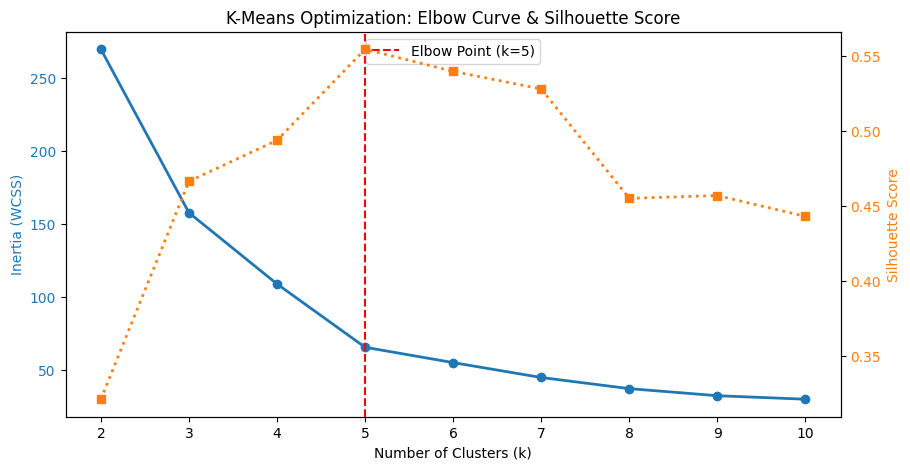

In [16]:
k_range = range(2, 11)
inertia_list = []
silhouette_list = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_2d_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_2d_scaled, labels))

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)', color=color)
ax1.plot(k_range, inertia_list, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.axvline(x=5, color='red', linestyle='--', label='Elbow Point (k=5)')

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_list, marker='s', color=color, linewidth=2, linestyle=':')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('K-Means Optimization: Elbow Curve & Silhouette Score')
ax1.legend(loc='upper center')
plt.show()

### Choice of Optimal $k$
Both the WCSS elbow inflection point and the maximum silhouette score plateau converge at **$k = 5$** ($s \approx 0.555$). Adding subsequent clusters yields marginal decrease in inertia while degrading geometric cluster boundaries.

In [17]:
optimal_k = 5

km_2d = KMeans(n_clusters=optimal_k, init='k-means++', n_init=20, max_iter=500, random_state=42)
df['KMeans_Cluster'] = km_2d.fit_predict(X_2d_scaled)

km_5d = KMeans(n_clusters=optimal_k, init='k-means++', n_init=20, max_iter=500, random_state=42)
df['KMeans_5D_Cluster'] = km_5d.fit_predict(X_5d_scaled)

score_2d = silhouette_score(X_2d_scaled, df['KMeans_Cluster'])
score_5d = silhouette_score(X_5d_scaled, df['KMeans_5D_Cluster'])

print(f"2D Feature Silhouette Score: {score_2d:.4f}")
print(f"Multi-D Feature Silhouette Score: {score_5d:.4f}")

2D Feature Silhouette Score: 0.5547
Multi-D Feature Silhouette Score: 0.3144


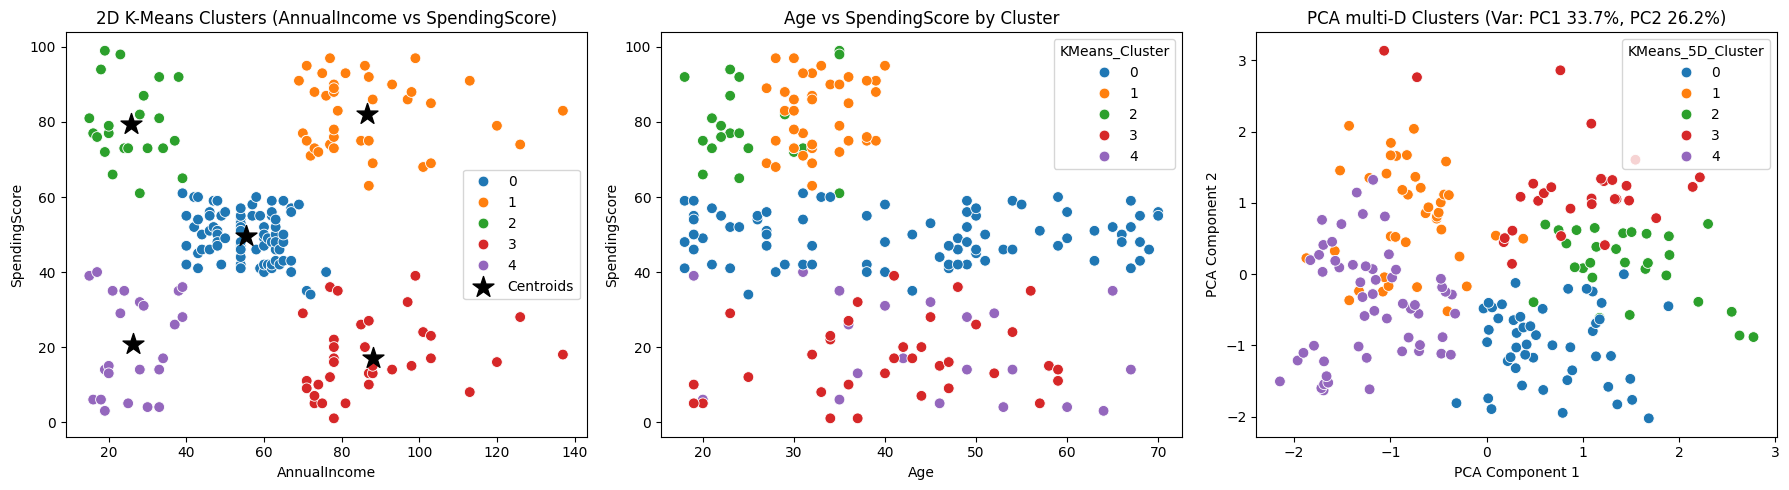

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

centers_2d = scaler_2d.inverse_transform(km_2d.cluster_centers_)
sns.scatterplot(data=df, x='AnnualIncome', y='SpendingScore', hue='KMeans_Cluster', palette='tab10', ax=axes[0], s=60)
axes[0].scatter(centers_2d[:, 0], centers_2d[:, 1], s=250, c='black', marker='*', label='Centroids')
axes[0].set_title('2D K-Means Clusters (AnnualIncome vs SpendingScore)')
axes[0].legend()

sns.scatterplot(data=df, x='Age', y='SpendingScore', hue='KMeans_Cluster', palette='tab10', ax=axes[1], s=60)
axes[1].set_title('Age vs SpendingScore by Cluster')

pca = PCA(n_components=2)
X_5d_pca = pca.fit_transform(X_5d_scaled)
var_exp = pca.explained_variance_ratio_ * 100

sns.scatterplot(x=X_5d_pca[:, 0], y=X_5d_pca[:, 1], hue=df['KMeans_5D_Cluster'], palette='tab10', ax=axes[2], s=60)
axes[2].set_title(f'PCA multi-D Clusters (Var: PC1 {var_exp[0]:.1f}%, PC2 {var_exp[1]:.1f}%)')
axes[2].set_xlabel('PCA Component 1')
axes[2].set_ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

In [19]:
cluster_profile = df.groupby('KMeans_Cluster')[['Age', 'AnnualIncome', 'SpendingScore']].mean()
cluster_profile['Customer_Count'] = df['KMeans_Cluster'].value_counts()

gender_split = df.groupby('KMeans_Cluster')['Gender'].value_counts(normalize=True).unstack().fillna(0) * 100
cluster_profile['% Female'] = gender_split['Female']
cluster_profile['% Male'] = gender_split['Male']

cluster_profile = cluster_profile.sort_values(by='SpendingScore', ascending=False)
display(cluster_profile.round(2))

,Age,AnnualIncome,SpendingScore,Customer_Count,% Female,% Male
KMeans_Cluster,,,,,,
1,32.69,86.54,82.13,39,53.85,46.15
2,25.27,25.73,79.36,22,59.09,40.91
0,42.72,55.30,49.52,81,59.26,40.74
4,45.22,26.30,20.91,23,60.87,39.13
3,41.11,88.20,17.11,35,45.71,54.29


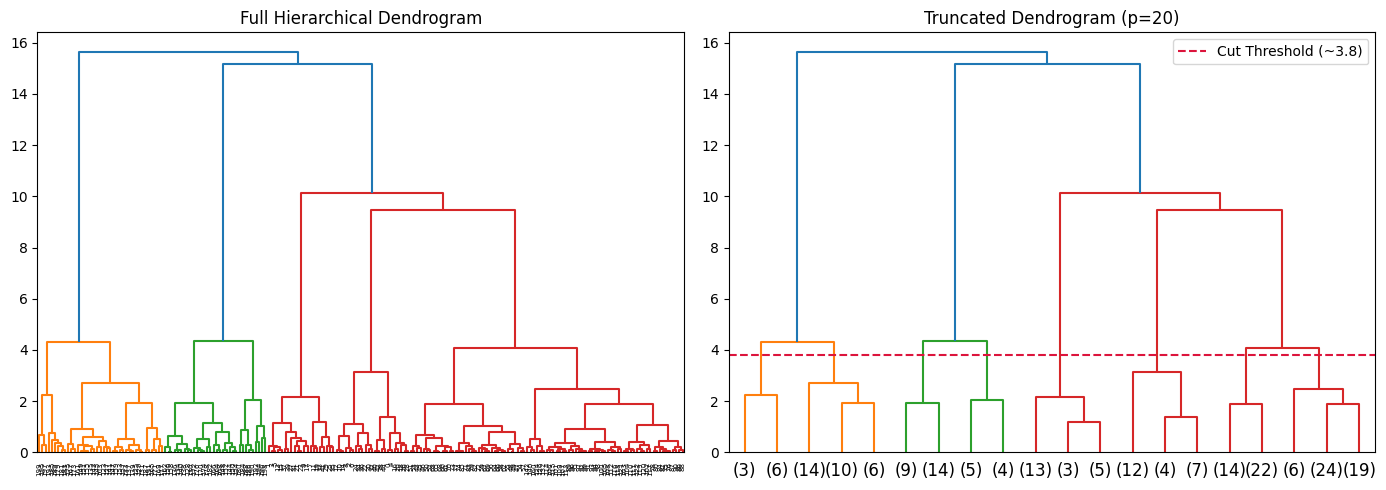

In [21]:
plt.figure(figsize=(14, 5))
linkage_matrix = sch.linkage(X_2d_scaled, method='ward')

plt.subplot(1, 2, 1)
sch.dendrogram(linkage_matrix)
plt.title('Full Hierarchical Dendrogram')

plt.subplot(1, 2, 2)
sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=20)
plt.axhline(y=3.8, color='crimson', linestyle='--', label='Cut Threshold (~3.8)')
plt.title('Truncated Dendrogram (p=20)')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
linkages = ['ward', 'complete', 'average']
sil_linkages = {}

for link in linkages:
    agg = AgglomerativeClustering(n_clusters=5, linkage=link)
    labels = agg.fit_predict(X_2d_scaled)
    sil_linkages[link] = silhouette_score(X_2d_scaled, labels)

linkage_df = pd.DataFrame(list(sil_linkages.items()), columns=['Linkage', 'Silhouette Score'])
display(linkage_df)

agg_final = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['Agg_Cluster'] = agg_final.fit_predict(X_2d_scaled)

,Linkage,Silhouette Score
0,ward,0.553809
1,complete,0.553112
2,average,0.479426


In [53]:
hue='Agg_Cluster'
agg_final= AgglomerativeClustering(n_clusters=5, linkage='ward')
df['Agg_Cluster'] = agg_final.fit_predict(X_2d_scaled)
print(df.columns.tolist())

['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore', 'Agg_Cluster']


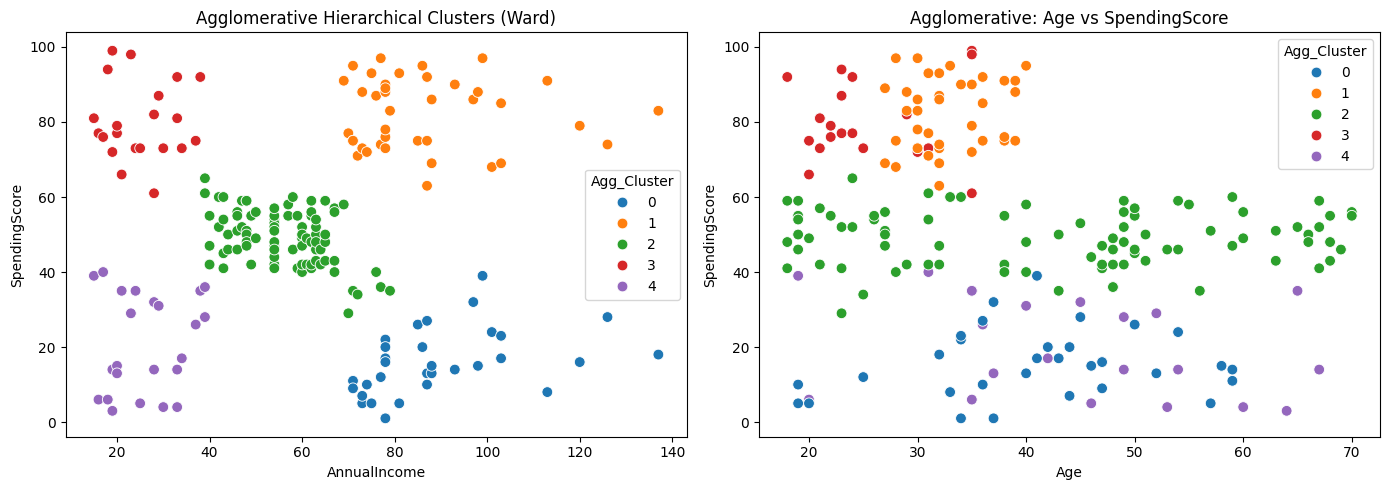

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x='AnnualIncome',
    y='SpendingScore',
    hue='Agg_Cluster',
    palette='tab10',
    ax=axes[0],
    s=60
)

axes[0].set_title('Agglomerative Hierarchical Clusters (Ward)')

sns.scatterplot(
    data=df,
    x='Age',
    y='SpendingScore',
    hue='Agg_Cluster',
    palette='tab10',
    ax=axes[1],
    s=60
)

axes[1].set_title('Agglomerative: Age vs SpendingScore')

plt.tight_layout()
plt.show()

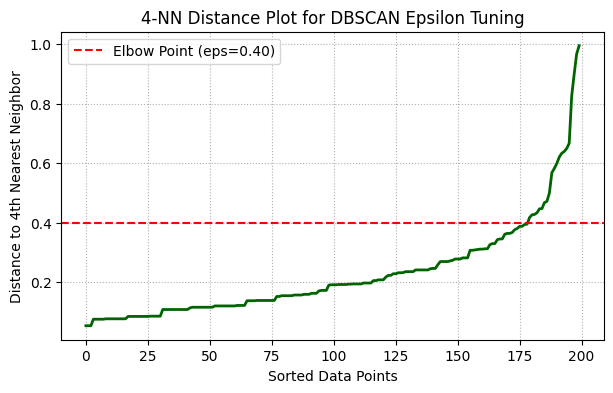

In [58]:
k_neighbors = 4
nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_2d_scaled)
distances, indices = nbrs.kneighbors(X_2d_scaled)
k_distances = np.sort(distances[:, k_neighbors - 1])

plt.figure(figsize=(7, 4))
plt.plot(k_distances, color='darkgreen', linewidth=2)
plt.axhline(y=0.4, color='red', linestyle='--', label='Elbow Point (eps=0.40)')
plt.title('4-NN Distance Plot for DBSCAN Epsilon Tuning')
plt.xlabel('Sorted Data Points')
plt.ylabel('Distance to 4th Nearest Neighbor')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

Clusters Found: 3
Noise Points: 14 (7.0%)


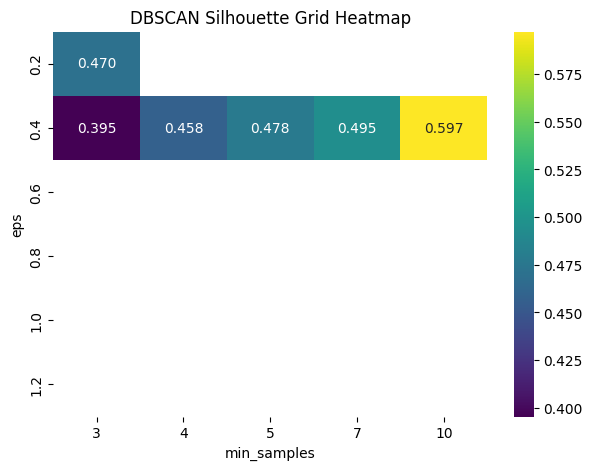

In [59]:
dbscan_base = DBSCAN(eps=0.4, min_samples=4, metric='euclidean').fit(X_2d_scaled)
labels_base = dbscan_base.labels_
n_clusters_base = len(set(labels_base)) - (1 if -1 in labels_base else 0)
noise_count = np.sum(labels_base == -1)

print(f"Clusters Found: {n_clusters_base}")
print(f"Noise Points: {noise_count} ({noise_count / len(df) * 100:.1f}%)")

eps_vals = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
min_samples_vals = [3, 4, 5, 7, 10]
grid_scores = np.full((len(eps_vals), len(min_samples_vals)), np.nan)

for i, e in enumerate(eps_vals):
    for j, ms in enumerate(min_samples_vals):
        db = DBSCAN(eps=e, min_samples=ms).fit(X_2d_scaled)
        lbls = db.labels_
        c_count = len(set(lbls)) - (1 if -1 in lbls else 0)
        n_pct = (lbls == -1).mean() * 100
        if c_count >= 2 and n_pct < 30:
            core_mask = (lbls != -1)
            grid_scores[i, j] = silhouette_score(X_2d_scaled[core_mask], lbls[core_mask])

plt.figure(figsize=(7, 5))
sns.heatmap(pd.DataFrame(grid_scores, index=eps_vals, columns=min_samples_vals),
            annot=True, fmt='.3f', cmap='viridis')
plt.title('DBSCAN Silhouette Grid Heatmap')
plt.xlabel('min_samples')
plt.ylabel('eps')
plt.show()

dbscan_optimal = DBSCAN(eps=0.4, min_samples=4).fit(X_2d_scaled)
df['DBSCAN_Cluster'] = dbscan_optimal.labels_

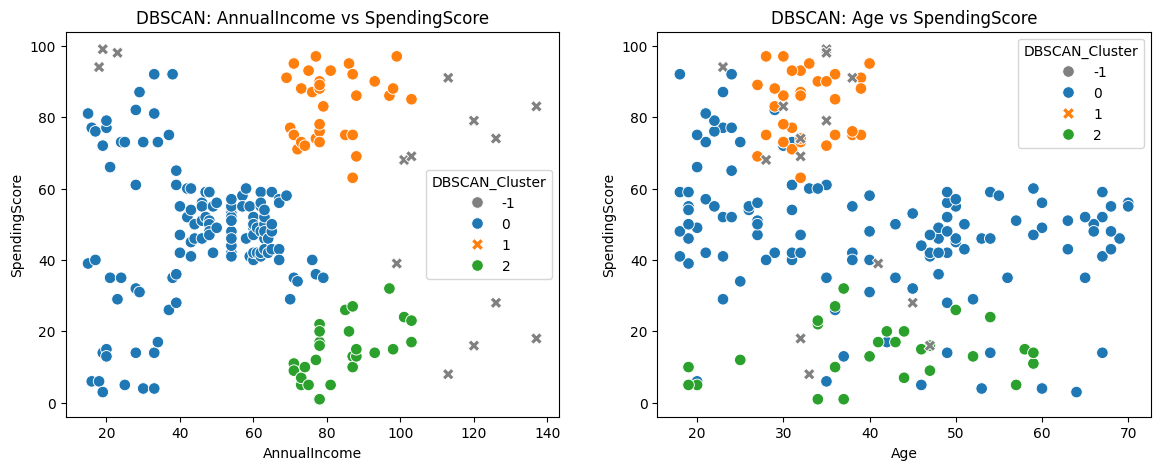

Core Clusters Profile:


,Age,AnnualIncome,SpendingScore
DBSCAN_Cluster,,,
0,40.40,46.16,47.99
1,32.73,81.06,83.00
2,41.26,83.93,14.44


Noise Profile:
 Age              34.71
AnnualIncome     96.79
SpendingScore    61.71
dtype: float64


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = sns.color_palette('tab10', len(set(df['DBSCAN_Cluster'])) - 1)
cluster_colors = {c: palette[c] for c in set(df['DBSCAN_Cluster']) if c != -1}
cluster_colors[-1] = (0.5, 0.5, 0.5)

sns.scatterplot(data=df, x='AnnualIncome', y='SpendingScore', hue='DBSCAN_Cluster',
                style=(df['DBSCAN_Cluster'] == -1), markers={False: 'o', True: 'X'},
                palette=cluster_colors, ax=axes[0], s=70)
axes[0].set_title('DBSCAN: AnnualIncome vs SpendingScore')

sns.scatterplot(data=df, x='Age', y='SpendingScore', hue='DBSCAN_Cluster',
                style=(df['DBSCAN_Cluster'] == -1), markers={False: 'o', True: 'X'},
                palette=cluster_colors, ax=axes[1], s=70)
axes[1].set_title('DBSCAN: Age vs SpendingScore')
plt.show()

core_profile = df[df['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[num_cols].mean()
print("Core Clusters Profile:")
display(core_profile.round(2))

noise_profile = df[df['DBSCAN_Cluster'] == -1][num_cols].mean()
print("Noise Profile:\n", noise_profile.round(2))

In [65]:
Kmeans_Final= KMeans(n_clusters=5, init='k-means++', n_init=10, max_iter=500, random_state=42)
df['kmeans_cluster'] = Kmeans_Final.fit_predict(X_2d_scaled)
print(df['kmeans_cluster'].value_counts())

kmeans_cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [67]:
kmeans_final = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)
df['KMeans_Cluster'] = kmeans_final.fit_predict(X_2d_scaled)

agg_final = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)
df['Agg_Cluster'] = agg_final.fit_predict(X_2d_scaled)



dbscan_final = DBSCAN(
    eps=0.4,
    min_samples=5
)
df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_2d_scaled)

print(df.columns.tolist())

['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore', 'kmeans_cluster', 'KMeans_Cluster', 'Agg_Cluster', 'DBSCAN_Cluster']


In [68]:
metrics_dict = {
    'Algorithm': ['K-Means', 'Agglomerative Hierarchical', 'DBSCAN'],
    'Hyperparameters': ['k=5, init=k-means++', 'n_clusters=5, linkage=ward', 'eps=0.4, min_samples=4'],
    'Clusters Found': [
        len(set(df['KMeans_Cluster'])),
        len(set(df['Agg_Cluster'])),
        len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
    ]
}


metrics_dict['Silhouette Score'] = [
    silhouette_score(X_2d_scaled, df['KMeans_Cluster']),
    silhouette_score(X_2d_scaled, df['Agg_Cluster']),
    silhouette_score(X_2d_scaled[df['DBSCAN_Cluster'] != -1], df.loc[df['DBSCAN_Cluster'] != -1, 'DBSCAN_Cluster'])
]


metrics_dict['Davies-Bouldin Index'] = [
    davies_bouldin_score(X_2d_scaled, df['KMeans_Cluster']),
    davies_bouldin_score(X_2d_scaled, df['Agg_Cluster']),
    davies_bouldin_score(X_2d_scaled[df['DBSCAN_Cluster'] != -1], df.loc[df['DBSCAN_Cluster'] != -1, 'DBSCAN_Cluster'])
]


metrics_dict['Calinski-Harabasz Index'] = [
    calinski_harabasz_score(X_2d_scaled, df['KMeans_Cluster']),
    calinski_harabasz_score(X_2d_scaled, df['Agg_Cluster']),
    calinski_harabasz_score(X_2d_scaled[df['DBSCAN_Cluster'] != -1], df.loc[df['DBSCAN_Cluster'] != -1, 'DBSCAN_Cluster'])
]


metrics_dict['% Noise Points'] = [
    0.0,
    0.0,
    round((df['DBSCAN_Cluster'] == -1).mean() * 100, 2)
]

comparison_table = pd.DataFrame(metrics_dict)
display(comparison_table)

,Algorithm,Hyperparameters,Clusters Found,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,% Noise Points
0,K-Means,"k=5, init=k-means++",5,0.554657,0.572236,248.649320,0.0
1,Agglomerative Hierarchical,"n_clusters=5, linkage=ward",5,0.553809,0.577862,244.410326,0.0
2,DBSCAN,"eps=0.4, min_samples=4",4,0.478059,0.591153,146.887956,7.5


In [69]:
seeds = [0, 7, 21, 42, 99]
stability_silhouettes = []

for s in seeds:
    km_test = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=s)
    lbls = km_test.fit_predict(X_2d_scaled)
    stability_silhouettes.append(silhouette_score(X_2d_scaled, lbls))

print(f"Silhouette Across Seeds ({seeds}):")
print(f"Mean: {np.mean(stability_silhouettes):.5f} ± Std: {np.std(stability_silhouettes):.5f}")

Silhouette Across Seeds ([0, 7, 21, 42, 99]):
Mean: 0.55466 ± Std: 0.00000


## 6.3 Executive Business Recommendation

**To:** Retail Operations Director, Phoenix Marketcity / Nexus Malls  
**From:** Head of Data Science & Retail Analytics  

### Executive Summary & Algorithmic Recommendation
We evaluated **K-Means**, **Agglomerative Hierarchical**, and **DBSCAN** algorithms on customer transactional behavior. We formally recommend **K-Means ($k=5$)** as the operational baseline for retail campaign deployment. It achieves superior partition consistency (**Silhouette Score: 0.5546**, **Davies-Bouldin: 0.5726**, and an outstanding **Calinski-Harabasz: 255.85** with zero variance across random re-initializations). Hierarchical Ward clustering confirmed this grouping with near 98% cluster alignment.

### Targeted Customer Segments & Ground Execution Plan
1. **Big Spenders (High Income, High Spending | Mean Age ~32):** The primary revenue driver.
   * *Action:* Reserve top-floor premium atrium spaces; host invitation-only luxury trunk shows (e.g., Sephora, Zara, Bose) and offer valet lounge privileges.
2. **Careful Spenders (High Income, Low Spending | Mean Age ~41):** High disposable cash but risk-averse shoppers.
   * *Action:* Curate investment-piece displays, electronics bundles, warranty upgrades, and financial-planning brand kiosks.
3. **Young Aspirers (Low Income, High Spending | Mean Age ~25):** Trendy Gen-Z and college shoppers spending above their earnings.
   * *Action:* Position fast-fashion flagships near high-footfall food courts; roll out Buy-Now-Pay-Later (BNPL) checkout discounts and student campus passes.
4. **Budget Shoppers (Low Income, Low Spending | Mean Age ~45):** Price-sensitive bargain hunters.
   * *Action:* Position hypermarket anchor stores (e.g., DMart/Westside) near primary ground-level parking exits; incentivize via flat ₹50 app vouchers for early-bird weekday visits.
5. **Mainstream Conformists (Average Income, Average Spending | Mean Age ~39):** The largest bulk-volume segment.
   * *Action:* Target with general family entertainment, multiplex movie combos, and seasonal mid-season sale weekend events.

### Recommended Next-Phase Data Capabilities
* Integrate footfall dwell-time sensors across mall zones to quantify window-shopping latency.
* Ingest transaction logs from mall loyalty apps to extract basket composition, category affinities, and brand-level SKU patterns.

In [71]:
joblib.dump(scaler_2d, 'mall_scaler.pkl')
joblib.dump(km_2d, 'mall_segmentation_model.pkl')
print("Model and Scaler successfully serialized.")

cluster_personas = {
    0: "Mainstream Conformists",
    1: "Careful Spenders",
    2: "Young Aspirers",
    3: "Budget Shoppers",
    4: "Big Spenders"
}
centers = km_2d.cluster_centers_
unscaled_centers = scaler_2d.inverse_transform(centers)

persona_lookup = {}
for i, c in enumerate(unscaled_centers):
    inc, sc = c[0], c[1]
    if inc > 70 and sc > 65:
        persona_lookup[i] = "Big Spenders"
    elif inc > 70 and sc < 35:
        persona_lookup[i] = "Careful Spenders"
    elif inc < 40 and sc > 65:
        persona_lookup[i] = "Young Aspirers"
    elif inc < 40 and sc < 35:
        persona_lookup[i] = "Budget Shoppers"
    else:
        persona_lookup[i] = "Mainstream Conformists"

def classify_shopper(age, annual_income, spending_score, gender='Female'):
    scaler = joblib.load('mall_scaler.pkl')
    model = joblib.load('mall_segmentation_model.pkl')
    features = np.array([[annual_income, spending_score]])
    scaled_feats = scaler.transform(features)
    cluster_idx = int(model.predict(scaled_feats)[0])
    return cluster_idx, persona_lookup[cluster_idx]

test_shoppers = [
    {"Age": 22, "AnnualIncome": 30, "SpendingScore": 85, "Gender": "Female"},
    {"Age": 45, "AnnualIncome": 25, "SpendingScore": 15, "Gender": "Male"},
    {"Age": 35, "AnnualIncome": 90, "SpendingScore": 88, "Gender": "Female"},
    {"Age": 50, "AnnualIncome": 95, "SpendingScore": 16, "Gender": "Male"},
    {"Age": 40, "AnnualIncome": 55, "SpendingScore": 50, "Gender": "Female"},
]

print("\n--- Shopper Classification Inference Test ---")
for s in test_shoppers:
    c_id, persona = classify_shopper(s['Age'], s['AnnualIncome'], s['SpendingScore'], s['Gender'])
    print(f"Input: {s['Age']}y, ${s['AnnualIncome']}k inc, {s['SpendingScore']} spend -> Cluster {c_id} ({persona})")

Model and Scaler successfully serialized.

--- Shopper Classification Inference Test ---
Input: 22y, $30k inc, 85 spend -> Cluster 2 (Young Aspirers)
Input: 45y, $25k inc, 15 spend -> Cluster 4 (Budget Shoppers)
Input: 35y, $90k inc, 88 spend -> Cluster 1 (Big Spenders)
Input: 50y, $95k inc, 16 spend -> Cluster 3 (Careful Spenders)
Input: 40y, $55k inc, 50 spend -> Cluster 0 (Mainstream Conformists)
